In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/online_retail.csv.zip')

სტრუქტურა:


In [ ]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


საბაზისო სტატისტიკა:

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
#გამოტოვებული მნიშვნელობების შეცვლა
print("გამოტოვებული მნიშვნელობები")
print(df.isnull().sum())

გამოტოვებული მნიშვნელობები
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
df = df.dropna(subset=['Description'])
df['CustomerID'] = df['CustomerID'].fillna(0).astype(int)

In [ ]:
#დუპლიკატების წაშლა
df = df.drop_duplicates()

In [ ]:
print(df.shape[0])

535187


In [ ]:
#ნეგატიური მნიშვნელობების გასწორება
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(df.shape[0])

524878


In [ ]:
#დროის კონვერტაცია
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
#ახალი დამხმარე სვეტები
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df['Month']       = df['InvoiceDate'].dt.month
df['DayOfWeek']   = df['InvoiceDate'].dt.day_name()

In [ ]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,Wednesday


თითოეული სვეტისთვის გამოტოვებული მნიშვნელობების წილი


In [ ]:
print(df.isnull().sum() / len(df) * 100)

InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
TotalAmount    0.0
Month          0.0
DayOfWeek      0.0
dtype: float64


რიცხვით სვეტების აუთლაიერების წილი

Quantity: 5.17%


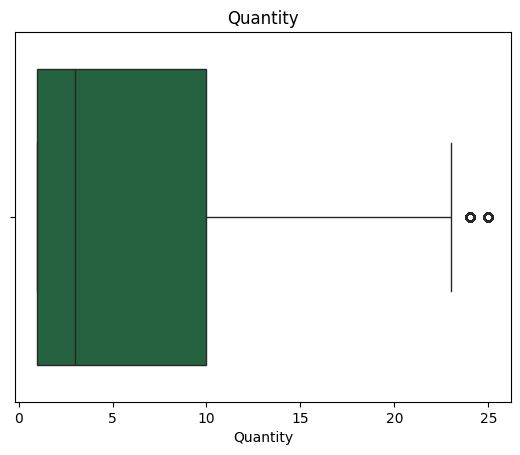

UnitPrice: 7.21%


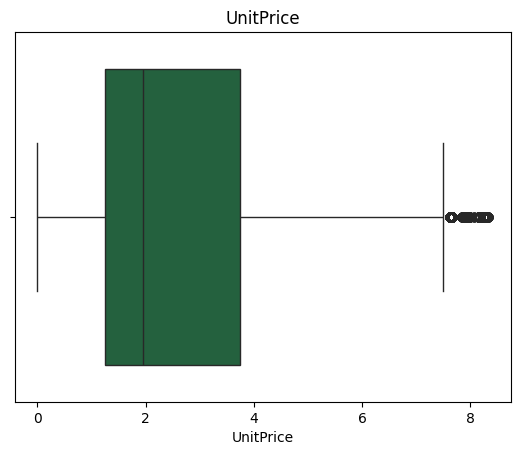

TotalAmount: 8.12%


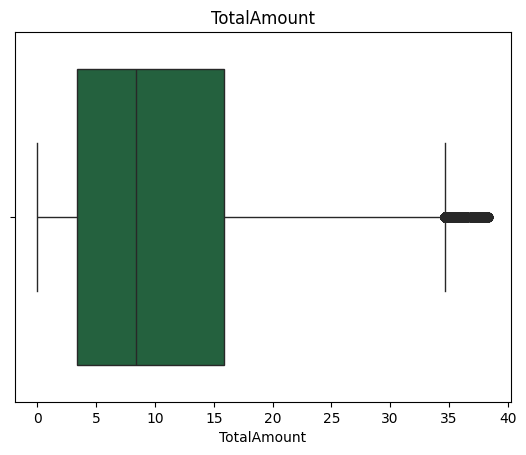

In [ ]:
for col in ['Quantity', 'UnitPrice', 'TotalAmount']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {round(len(outliers)/len(df)*100, 2)}%")
    sns.boxplot(x=df[(df[col] < upper) & (df[col] > lower)][col], color='#1a6b3c')
    plt.title(col)
    plt.show()


ტოპ 10 ყველაზე გაყიდვადი პროდუქტი

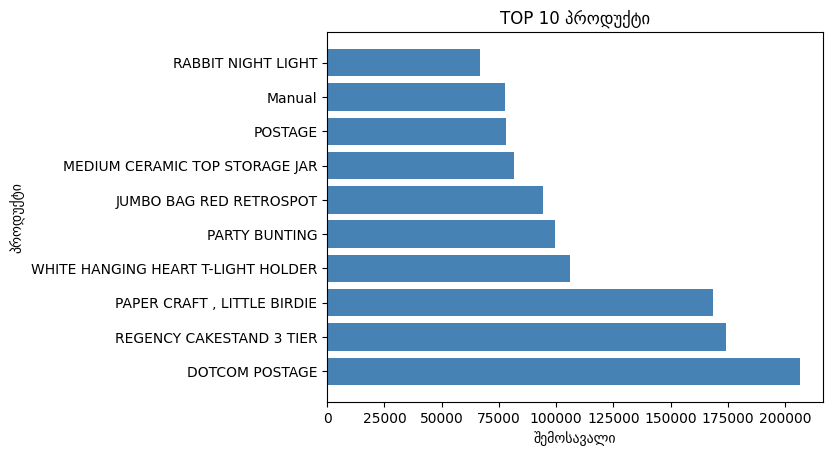

In [ ]:
top_products = df.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
plt.barh(top_products.index, top_products.values, color='steelblue')
plt.title('TOP 10 პროდუქტი')
plt.xlabel('შემოსავალი')
plt.ylabel('პროდუქტი')
plt.show()

ყველაზე მაღალი შემოსავლის ქვეყნები

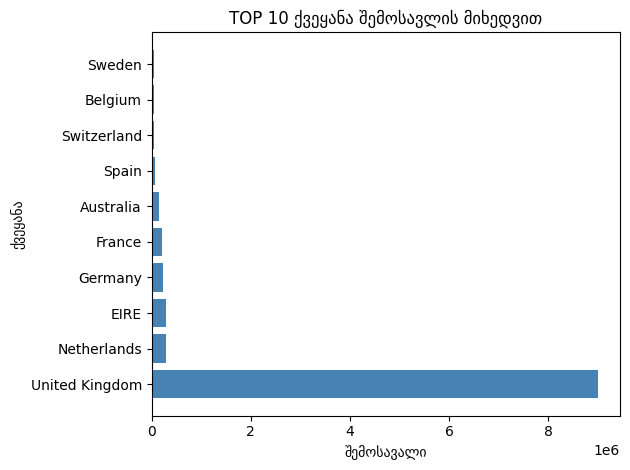

In [ ]:
top_countries = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
plt.barh(top_countries.index, top_countries.values, color='steelblue')
plt.title('TOP 10 ქვეყანა შემოსავლის მიხედვით')
plt.xlabel('შემოსავალი')
plt.ylabel('ქვეყანა')
plt.tight_layout()
plt.show()

სეზონურობა

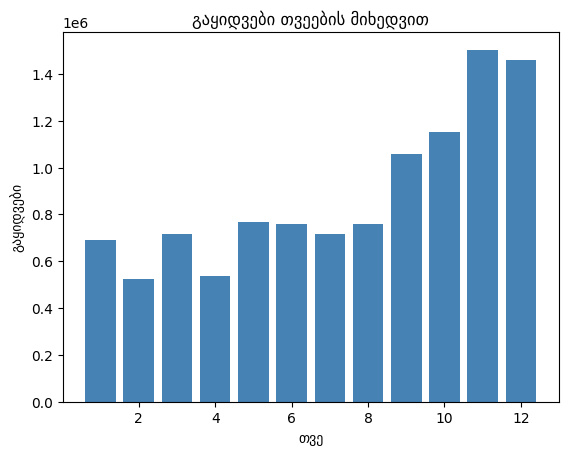

In [ ]:
monthly = df.groupby('Month')['TotalAmount'].sum().sort_values(ascending=False)
plt.bar(monthly.index, monthly.values, color='steelblue')
plt.title('გაყიდვები თვეების მიხედვით')
plt.xlabel('თვე')
plt.ylabel('გაყიდვები')
plt.show()

ყველაზე აქტიური კვირის დღე

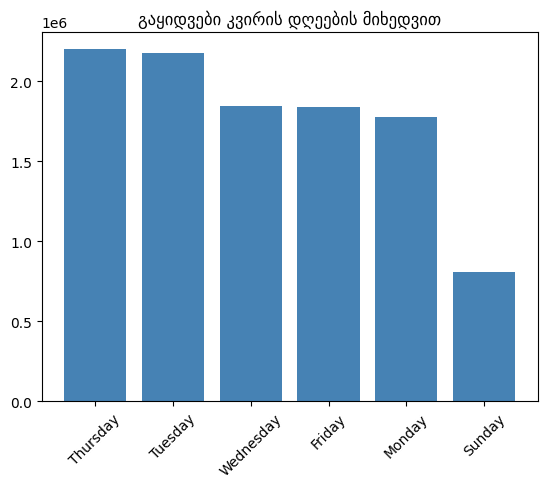

In [ ]:
daily = df.groupby('DayOfWeek')['TotalAmount'].sum().sort_values(ascending=False)
plt.bar(daily.index, daily.values, color='steelblue')
plt.title('გაყიდვები კვირის დღეების მიხედვით')
plt.xticks(rotation=45)
plt.show()

გაყიდვები საათების მიხედვით

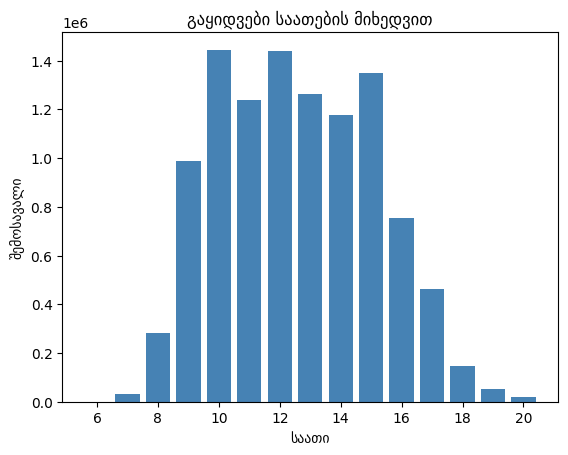

In [ ]:
df['Hour'] = df['InvoiceDate'].dt.hour
hourly = df.groupby('Hour')['TotalAmount'].sum().sort_index()
plt.bar(hourly.index, hourly.values, color='steelblue')
plt.title('გაყიდვები საათების მიხედვით')
plt.xlabel('საათი')
plt.ylabel('შემოსავალი')
plt.show()

ტოპ 10 მომხმარებელი

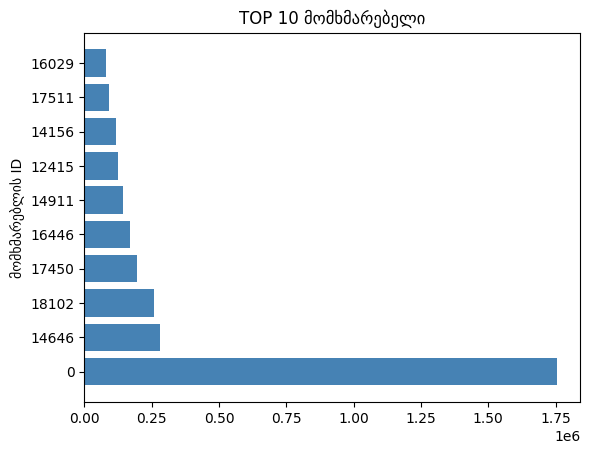

In [ ]:
top_customers = df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)
plt.barh(top_customers.index.astype(str), top_customers.values, color='steelblue')
plt.title('TOP 10 მომხმარებელი')
plt.ylabel('მომხმარებლის ID')
plt.show()

**დასკვნები:**

1. **DOTCOM POSTAGE, REGENCY CAKESTAND 3 TIER და PAPER CRAFT LITTLE BIRDIE** არის ყველაზე მომგებიანი პროდუქტები, ამიტომ მათზე განსაკუთრებული ყურადღება უნდა გაკეთდეს.
2. **დიდი ბრიტანეთი** არის მთავარი ბაზარი. შემოსავლის უდიდესი ნაწილი იქიდან მოდის.
3. **ოთხშაბათი და ხუთშაბათი** არის ყველაზე აქტიური დღეები, სწორედ ამ დღეებში ხდება ყველაზე მეტი გაყიდვა.
4. **10 საათიდან 13 საათამდე** არის ყველაზე მეტი გაყიდვა განხორციელებული.
5. **ნოემბერი და დეკემბერი** არის peak თვეები, ახალი წლის პერიოდში გაყიდვები მკვეთრად იზრდება.




**რეკომენდაციები:**
1. ზამთრის სეზონამდე მარაგების გაზრდა, განსაკუთრებით TOP პროდუქტებზე.
2. ოთხშაბათს და ხუთშაბათს სპეციალური აქციების და ფასდაკლებების შემოღება, განსაკუთრებით 10 საათიდან 13 საათამდე. ამ დღეებში ონლაინ მარკეტინგისთვის დიდი ბიუჯეტის გამოყოფა.
3. ბრიტანეთის ბაზარზე მეტი ინვესტიციის განხორციელება და ამ მარკეტის შესწავლა, რათა მოხდეს სხვა ქვეყნების მარკეტების განვითარება.
4. CustomerID-ის გამოტოვებული 25% მიუთითებს რომ ბევრი მომხმარებელი დაურეგისტრირებელია. სარეგისტრაციო სისტემის გაუმჯობესება რეკომენდირებულია.